In [1]:
import numpy as np
from data import *
import matplotlib.pyplot as plt

In [2]:
def visualize_data(X,y):
    fig ,ax = plt.subplots(figsize=(6,6))
    ax.scatter(X[y == 0, 0], X[y == 0, 1],c="red", label="Class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1],c="blue", label="Class 1")
    plt.legend()
    plt.show()

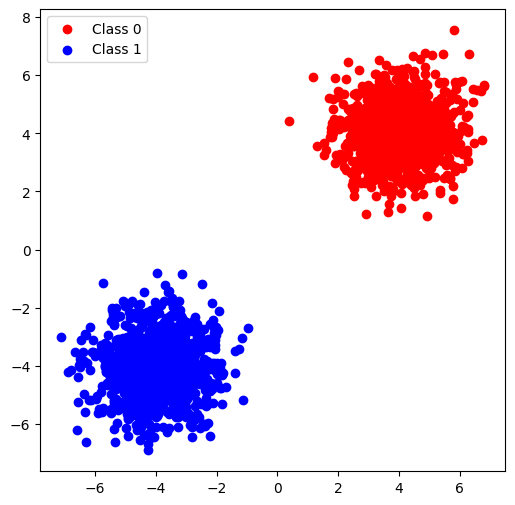

In [3]:

X,y,_ = load_bubbles()
visualize_data(X,y)

In [4]:
from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier
ENSEMBLE_MEMBER_COUNT = 20
base_ensemble = [MLP_Classifier(input_shape=2,n_classes=2,n_layers=2,num_neurons=64,dropout_prob=0,batch_norm=False,) for  _ in range(ENSEMBLE_MEMBER_COUNT)]
ensemble_model = Ensemble_Classifier(base_ensemble,n_models=ENSEMBLE_MEMBER_COUNT)
ensemble_model.load("models/Ensemble_Bubbles_50/")

In [5]:
X_label1 = X[y == 1]
X_label0 = X[y == 0]

point_of_interest = np.array([[3,3]])

In [6]:
def get_costs(epiuc_ensemble_model, X, point_of_interest, desired_class=1):
    """
    Calculate the costs for each point in X with respect to the point of interest.
    :param X: The data points
    :param point_of_interest: The point of interest
    :return: An array of costs
    """
    probabilities, uncertainties = epiuc_ensemble_model.predict(X, raw_output=True)
    tu, au, eu = torch.tensor_split(uncertainties.T, 3, dim=0)
    probabilities = probabilities.mean(dim=1).detach().numpy()[:,desired_class]  # Convert to log2 probabilities
    distances = np.linalg.norm(X - point_of_interest, axis=1)
    return np.vstack([au.detach().numpy(), eu.detach().numpy(),distances, probabilities]).T

In [7]:
# create grid of points
grid_points = np.linspace(X.min() - 2, X.max() + 2, 100)
xx, yy = np.meshgrid(grid_points, grid_points)
grid_points = np.array([xx.flatten(), yy.flatten()]).T


combined_costs = get_costs(ensemble_model,grid_points, point_of_interest)

In [8]:
def is_pareto_efficient(costs, return_mask = True):
    """
    Find the pareto-efficient points
    :param costs: An (n_points, n_costs) array
    :param return_mask: True to return a mask
    :return: An array of indices of pareto-efficient points.
        If return_mask is True, this will be an (n_points, ) boolean array
        Otherwise it will be a (n_efficient_points, ) integer array of indices.
    """
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0  # Next index in the is_efficient array to search for
    while next_point_index<len(costs):
        nondominated_point_mask = np.any(costs<costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]  # Remove dominated points
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index])+1
    if return_mask:
        is_efficient_mask = np.zeros(n_points, dtype = bool)
        is_efficient_mask[is_efficient] = True
        return is_efficient_mask
    else:
        return is_efficient

In [9]:
is_efficient = is_pareto_efficient(combined_costs)

pareto_front = grid_points[is_efficient]


probability, _  = ensemble_model.predict(pareto_front, raw_output=False)
mask = probability[:,1] > 0.5
pareto_front_no_cfs = pareto_front[~mask]
pareto_front_cfs = pareto_front[mask]

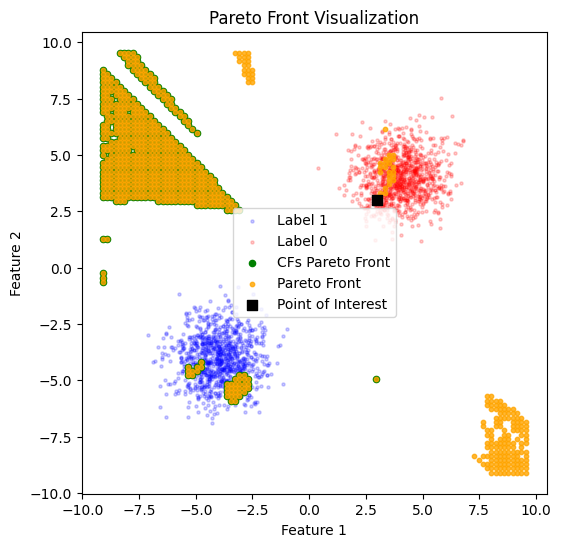

In [10]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X_label1[:,0], X_label1[:,1],s=5,alpha=.2, c="blue", label="Label 1")
ax.scatter(X_label0[:,0], X_label0[:,1],s=5,alpha=.2, c="red", label="Label 0")
ax.scatter(pareto_front_cfs[:,0], pareto_front_cfs[:,1],s=20, c="green",label="CFs Pareto Front")
ax.scatter(pareto_front[:,0], pareto_front[:,1], s=10,alpha=0.8,  c="orange", label="Pareto Front")
ax.scatter(point_of_interest[0,0], point_of_interest[0,1],s=50,marker="s", c="black", label="Point of Interest")
plt.legend()
plt.title("Pareto Front Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("pareto_front_visualization.pdf", dpi=300, bbox_inches='tight')
plt.show()

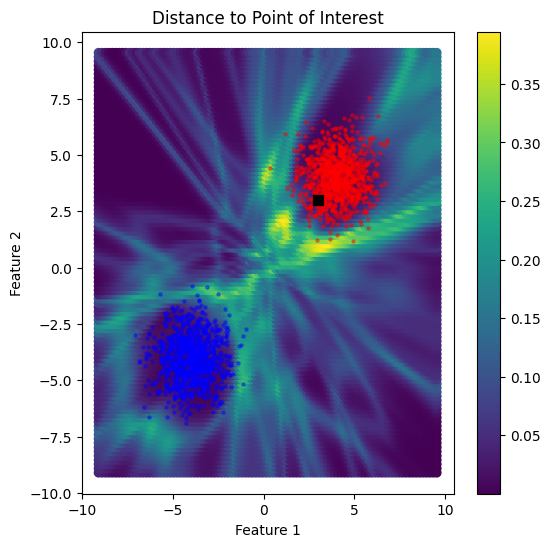

In [11]:
fig,ax = plt.subplots(figsize=(6,6))
plot = ax.scatter(grid_points[:,0], grid_points[:,1], c=combined_costs[:,0], label="Label 1")
ax.scatter(X_label1[:,0], X_label1[:,1],s=5,alpha=.4, c="blue", label="Label 1")
ax.scatter(X_label0[:,0], X_label0[:,1],s=5,alpha=.4, c="red", label="Label 0")
ax.scatter(point_of_interest[0,0], point_of_interest[0,1],s=50,marker="s", c="black", label="Point of Interest")
plt.colorbar(plot)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Distance to Point of Interest")
plt.savefig("pareto_front_visualization_distance.pdf", dpi=300, bbox_inches='tight')
plt.show()

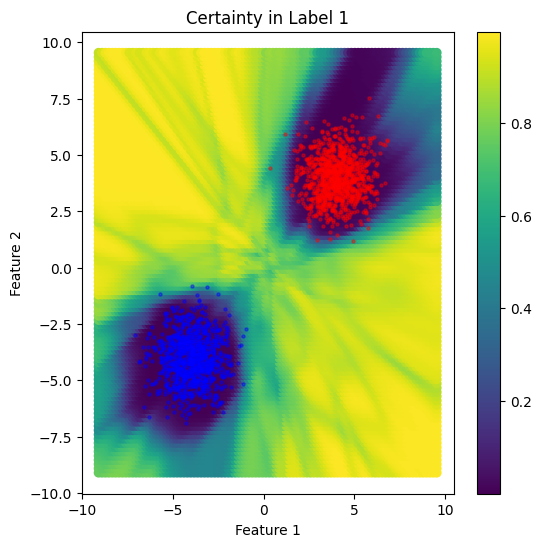

In [12]:
fig,ax = plt.subplots(figsize=(6,6))
plot = ax.scatter(grid_points[:,0], grid_points[:,1], c=combined_costs[:,1], label="Label 1")
ax.scatter(X_label1[:,0], X_label1[:,1],s=5,alpha=.4, c="blue", label="Label 1")
ax.scatter(X_label0[:,0], X_label0[:,1],s=5,alpha=.4, c="red", label="Label 0")
plt.colorbar(plot)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Certainty in Label 1")
plt.savefig("pareto_front_visualization_certainty.pdf", dpi=300, bbox_inches='tight')
plt.show()

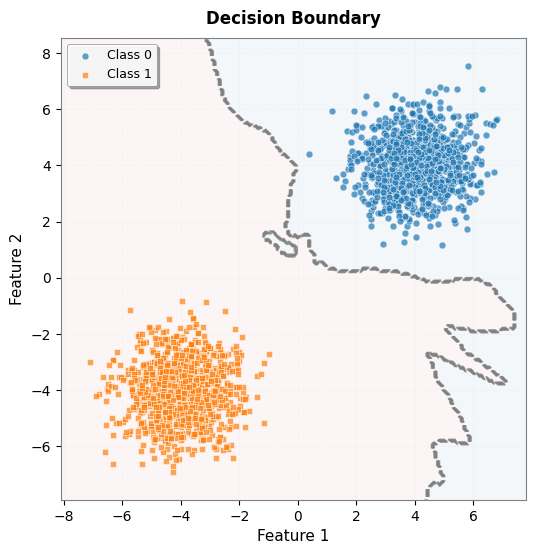

In [13]:
# visualize decision boundary
from property_procedures.utils import visualize_decision_boundry
fig,ax = plt.subplots(figsize=(6,6))
visualize_decision_boundry(ax, X, ensemble_model, y, dataset_name="")

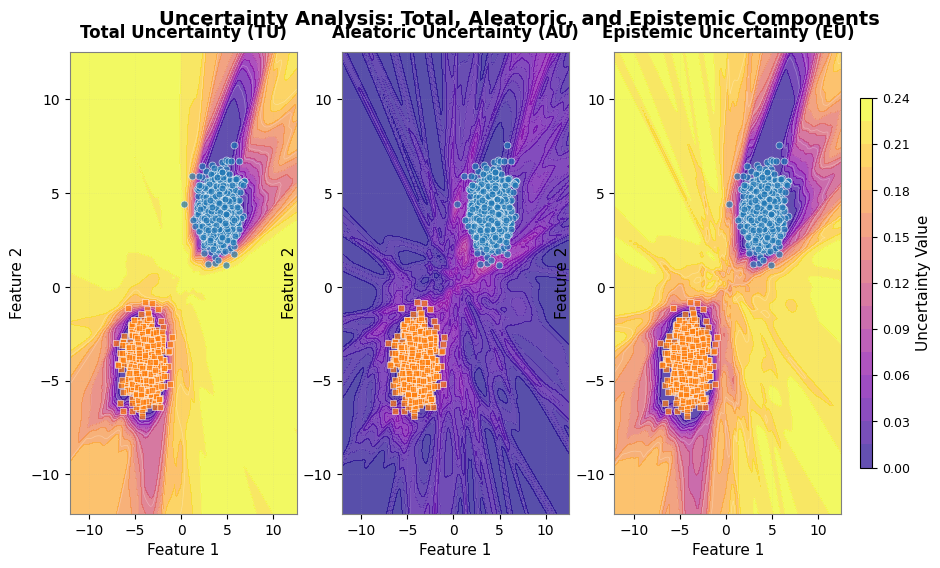

In [14]:
# visualize decision boundary
from property_procedures.utils import visualize_au_eu_tu

fig, ax = plt.subplots(figsize=(12, 6), ncols=3)
visualize_au_eu_tu(fig,ensemble_model,X,y,ax)

Plot 0: objectives 0 vs 1 at position (0, 0)
Plot 1: objectives 0 vs 2 at position (0, 1)
Plot 2: objectives 0 vs 3 at position (0, 2)
Plot 3: objectives 1 vs 2 at position (1, 0)
Plot 4: objectives 1 vs 3 at position (1, 1)
Plot 5: objectives 2 vs 3 at position (1, 2)


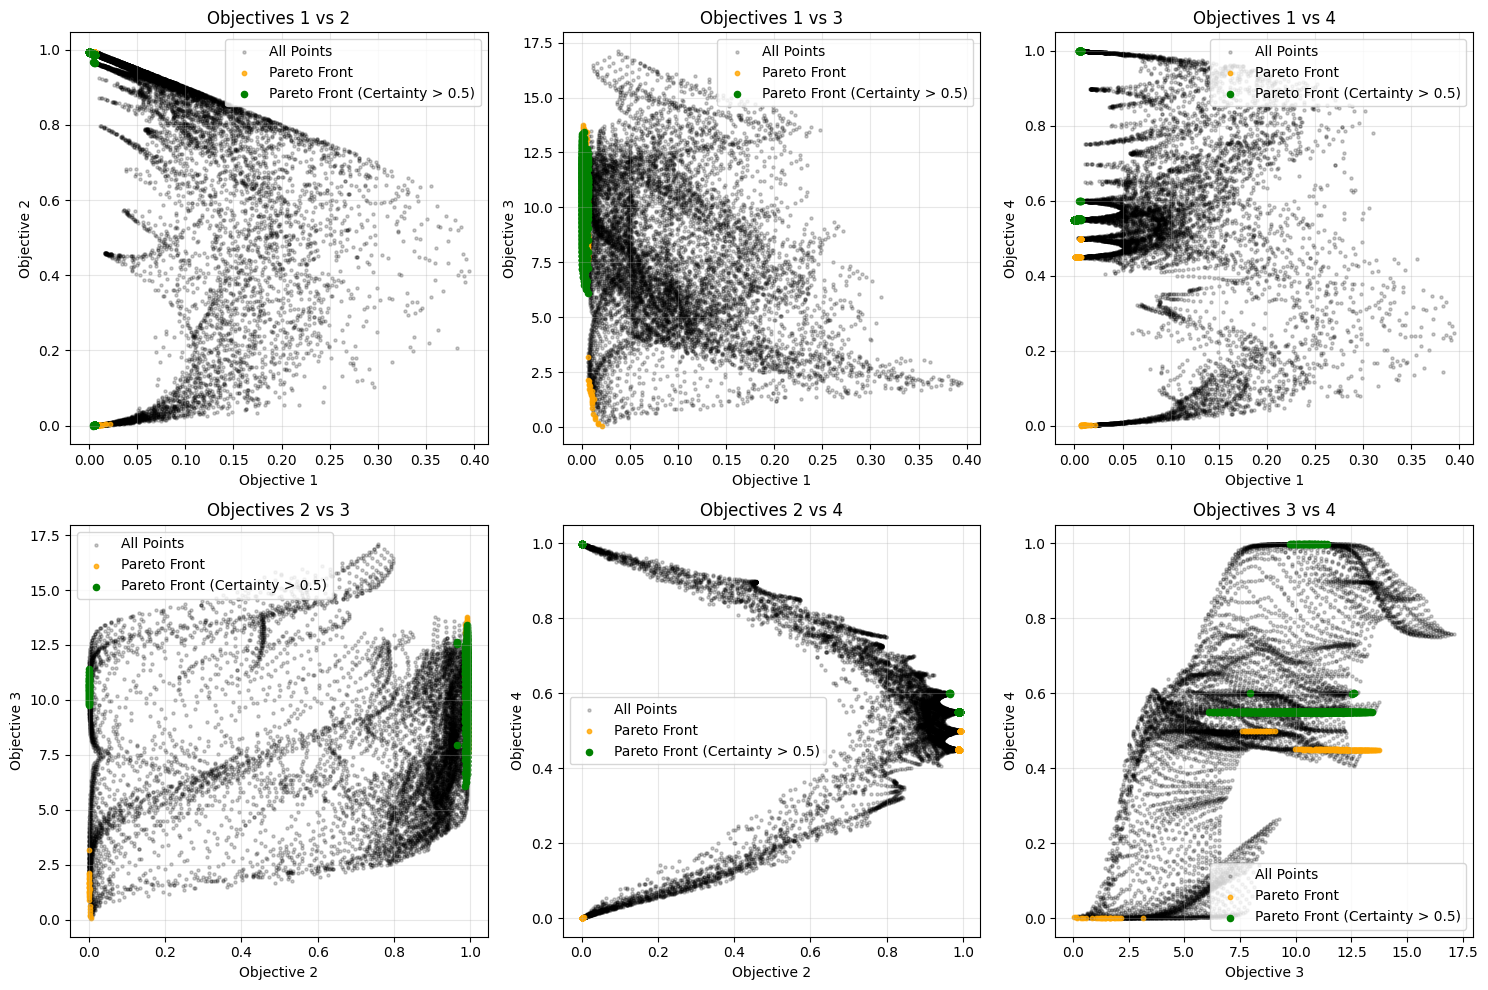

In [15]:
# visualize the points through costs and certainty
from itertools import combinations
import math

# Get all combinations of objectives (costs)
comb = list(combinations(range(combined_costs.shape[-1]), 2))
n_comb = len(comb)

# Calculate proper grid layout
n_cols = 3  # or 2, depending on your preference
n_rows = math.ceil(n_comb / n_cols)

fig, ax = plt.subplots(figsize=(15, 5*n_rows), nrows=n_rows, ncols=n_cols)

# Ensure ax is always 2D array
if n_rows == 1:
    ax = ax.reshape(1, -1)
if n_cols == 1:
    ax = ax.reshape(-1, 1)

# Get Pareto efficient points
pareto_efficient_mask = is_pareto_efficient(combined_costs)
pareto_costs = combined_costs[pareto_efficient_mask]

# Recalculate mask for Pareto front points
pareto_points = grid_points[pareto_efficient_mask]
probability, _ = ensemble_model.predict(pareto_points, raw_output=False)
mask = probability[:,1] > 0.5

for i, c in enumerate(comb):
    row_id = i // n_cols
    col_id = i % n_cols
    
    print(f"Plot {i}: objectives {c[0]} vs {c[1]} at position ({row_id}, {col_id})")
    
    # Plot all points
    ax[row_id, col_id].scatter(combined_costs[:,c[0]], combined_costs[:,c[1]], 
                              s=5, alpha=0.2, c="black", label="All Points")
    
    # Plot Pareto front
    ax[row_id, col_id].scatter(pareto_costs[:,c[0]], pareto_costs[:,c[1]],
                              c="orange", s=10, alpha=0.8, label="Pareto Front")
    
    # Plot Pareto front with high certainty
    ax[row_id, col_id].scatter(pareto_costs[mask,c[0]], pareto_costs[mask,c[1]],
                              c="green", s=20, label="Pareto Front (Certainty > 0.5)")

    ax[row_id, col_id].set_xlabel(f"Objective {c[0] + 1}")
    ax[row_id, col_id].set_ylabel(f"Objective {c[1] + 1}")
    ax[row_id, col_id].set_title(f"Objectives {c[0] + 1} vs {c[1] + 1}")
    ax[row_id, col_id].legend()
    ax[row_id, col_id].grid(True, alpha=0.3)

# Hide empty subplots
for i in range(n_comb, n_rows * n_cols):
    row_id = i // n_cols
    col_id = i % n_cols
    ax[row_id, col_id].set_visible(False)

plt.tight_layout()
plt.show()

# PYMOO 

In [16]:
def get_costs(epiuc_ensemble_model, X, point_of_interest, desired_class=1):
    """
    Calculate the costs for each point in X with respect to the point of interest.
    :param X: The data points
    :param point_of_interest: The point of interest
    :return: An array of costs
    """
    probabilities, uncertainties = epiuc_ensemble_model.predict(X, raw_output=True)
    tu, au, eu = torch.tensor_split(uncertainties.T, 3, dim=0)
    probabilities = (
        probabilities.mean(dim=1).detach().numpy()[:, desired_class]
    )  # Convert to log2 probabilities
    distances = np.linalg.norm(X - point_of_interest, axis=1)
    return np.vstack(
        [au.detach().numpy(), eu.detach().numpy(), distances, probabilities]
    ).T

In [17]:
from pymoo.core.problem import Problem

class BaseProblem(Problem):
    def __init__(self, ensemble_model, point_of_interest, min_x, max_x, n_features, n_obj, cost_func):
        super().__init__(
            n_var=n_features,
            n_obj=n_obj,
            n_ieq_constr=1,
            xl=np.repeat(math.floor(min_x) - 1, n_features),
            xu=np.repeat(math.floor(max_x) + 1, n_features),
        )
        self.model = ensemble_model
        self.point_of_interest = point_of_interest
        self.cost_func = cost_func
        
    def _evaluate(self, x, out, *args, desired_class=1, **kwargs):
        raise NotImplementedError("This method should be implemented by subclasses.")

class Model_Fixed_Decision_Deterministic(BaseProblem):

    def __init__(self, ensemble_model, point_of_interest,min_x,max_x,n_features, cost_func):
        super().__init__(
            ensemble_model=ensemble_model,
            point_of_interest=point_of_interest,
            min_x=min_x,
            max_x=max_x,
            n_features=n_features,
            n_obj=1,
            cost_func=cost_func
        )
        self.model = ensemble_model
        self.point_of_interest = point_of_interest

    def _evaluate(self, x, out, *args, desired_class=1, **kwargs):
        costs = self.cost_func(self.model, x, self.point_of_interest, desired_class=desired_class)
        f3 = costs[:, 2]  # Distance
        g1 = 0.51 - costs[:, 3]  # Some constraint

        out["F"] = [f3]
        out["G"] = [g1]


class Model_Fixed_Decision_Stochastic(BaseProblem):

    def __init__(self, ensemble_model, point_of_interest, min_x, max_x,n_features, cost_func):
        super().__init__(
            ensemble_model=ensemble_model,
            point_of_interest=point_of_interest,
            min_x=min_x,
            max_x=max_x,
            n_features=n_features,
            n_obj=2,
            cost_func=cost_func
        )
        self.model = ensemble_model
        self.point_of_interest = point_of_interest

    def _evaluate(self, x, out, *args, desired_class=1, **kwargs):
        costs = self.cost_func(self.model, x, self.point_of_interest, desired_class=desired_class)
        f1 = costs[:, 0]  # AU
        f3 = costs[:, 2]  # Distance
        g1 = 0.51 - costs[:, 3]  # Some constraint

        out["F"] = [f1, f3]
        out["G"] = [g1]


class Model_Stochastic_Decision_Fixed(BaseProblem):

    def __init__(self, ensemble_model, point_of_interest, min_x, max_x, n_features, cost_func):
        super().__init__(
            ensemble_model=ensemble_model,
            point_of_interest=point_of_interest,
            min_x=min_x,
            max_x=max_x,
            n_features=n_features,
            n_obj=2,
            cost_func=cost_func
        )
        self.model = ensemble_model
        self.point_of_interest = point_of_interest

    def _evaluate(self, x, out, *args, desired_class=1, **kwargs):
        costs = self.cost_func(self.model, x, self.point_of_interest, desired_class=desired_class)
        f2 = costs[:, 1]  # EU
        f3 = costs[:, 2]  # Distance
        g1 = 0.51 - costs[:, 3]  # Some constraint

        out["F"] = [f2, f3]
        out["G"] = [g1]


class Model_Stochastic_Decision_Stochastic(BaseProblem):

    def __init__(self, ensemble_model, point_of_interest, min_x, max_x, n_features, cost_func):
        super().__init__(
            ensemble_model=ensemble_model,
            point_of_interest=point_of_interest,
            min_x=min_x,
            max_x=max_x,
            n_features=n_features,
            n_obj=2,
            cost_func=cost_func
        )
        self.model = ensemble_model
        self.point_of_interest = point_of_interest

    def _evaluate(self, x, out, *args, desired_class=1, **kwargs):
        costs = self.cost_func(self.model, x, self.point_of_interest, desired_class=desired_class)
        f1 = costs[:, 0] + costs[:, 1]  # TU
        f3 = costs[:, 2]  # Distance
        g1 = 0.51 - costs[:, 3]  # Some constraint

        out["F"] = [f1, f3]
        out["G"] = [g1]


m_f_d_d = Model_Fixed_Decision_Deterministic(ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs)
m_f_d_s = Model_Fixed_Decision_Stochastic(ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs)
m_s_d_f = Model_Stochastic_Decision_Fixed(ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs)
m_s_d_s = Model_Stochastic_Decision_Stochastic(ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs)

In [18]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

from moo_nsgaii.algorithm import (
    NSGA_II_Counterfactual,
)

algorithm = NSGA2(
    pop_size=100,
    n_offsprings=10,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True,
)
algorithm = NSGA_II_Counterfactual(
    pop_size=5,
    original_point=point_of_interest,
    sigma_features=np.array([1,1])
)

In [19]:
from pymoo.termination import get_termination

termination = get_termination("n_gen", 200)

In [20]:
from pymoo.optimize import minimize

res_m_f_d_d = minimize(m_f_d_d, algorithm, termination=termination, seed=1, save_history=True, verbose=True)
res_m_f_d_s = minimize(m_f_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True)
res_m_s_d_f = minimize(m_s_d_f, algorithm, termination=termination, seed=1, save_history=True, verbose=True)
res_m_s_d_s = minimize(m_s_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True)

pareto_points_m_f_d_d = res_m_f_d_d.X
objetives_m_f_d_d = res_m_f_d_d.F

pareto_points_m_f_d_s = res_m_f_d_s.X
objetives_m_f_d_s = res_m_f_d_s.F

pareto_points_m_s_d_f = res_m_s_d_f.X
objetives_m_s_d_f = res_m_s_d_f.F

pareto_points_m_s_d_s = res_m_s_d_s.X
objetives_m_s_d_s = res_m_s_d_s.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |        5 |      1 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |       10 |      1 |  0.000000E+00 |  0.000000E+00 |  1.3429953113 |         ideal
     3 |       15 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0190411968 |         ideal
     4 |       20 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |       25 |      1 |  0.000000E+00 |  0.000000E+00 |  0.2991581360 |         ideal
     6 |       30 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0178708989 |         ideal
     7 |       35 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0698766903 |         ideal
     8 |       40 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0434165486 |         ideal
     9 |       45 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0314130596 |         ideal
    10 |       50 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0482000215 |         ideal

In [21]:
def visualize_pareto_objectives(objectives, title_prefix=""):

    # visualize the points through costs and certainty
    from itertools import combinations
    import math
    if len(objectives.shape) == 1:
        objectives = objectives[np.newaxis, :]

    # Get all combinations of objectives (costs)
    comb = list(combinations(range(objectives.shape[-1]), 2))
    n_comb = len(comb)

    # Calculate proper grid layout
    n_cols = 3  # or 2, depending on your preference
    n_rows = math.ceil(n_comb / n_cols)

    fig, ax = plt.subplots(figsize=(16, 6 * n_rows), nrows=n_rows, ncols=n_cols)
    
    # Set overall figure styling
    if title_prefix:
        fig.suptitle(f'{title_prefix}: Objective Space Analysis', 
                     fontsize=16, fontweight='bold', y=0.95)

    # Ensure ax is always 2D array
    if n_rows == 1:
        ax = ax.reshape(1, -1)
    if n_cols == 1:
        ax = ax.reshape(-1, 1)

    # Enhanced color scheme
    colors = {
        'all_points': '#E8E8E8',
        'pareto': '#FF6B35',
        'highlight': '#004E89'
    }
    
    # Objective labels
    obj_labels = ['Aleatoric Uncertainty', 'Epistemic Uncertainty', 'Distance', 'Probability']

    for i, c in enumerate(comb):
        row_id = i // n_cols
        col_id = i % n_cols

        # Plot all points with subtle styling
        ax[row_id, col_id].scatter(
            combined_costs[:, c[0]], combined_costs[:, c[1]],
            s=8, alpha=0.3, c=colors['all_points'], 
            edgecolors='gray', linewidth=0.2,
            label="All Points", zorder=1
        )

        # Plot Pareto front with enhanced styling
        ax[row_id, col_id].scatter(
            objectives[:, c[0]], objectives[:, c[1]],
            c=colors['pareto'], s=40, alpha=0.9,
            edgecolors='white', linewidth=1,
            label="Pareto Front", zorder=3
        )

        # Enhanced axis labels with proper names
        xlabel = obj_labels[c[0]] if c[0] < len(obj_labels) else f"Objective {c[0] + 1}"
        ylabel = obj_labels[c[1]] if c[1] < len(obj_labels) else f"Objective {c[1] + 1}"
        
        ax[row_id, col_id].set_xlabel(xlabel, fontsize=11, fontweight='medium')
        ax[row_id, col_id].set_ylabel(ylabel, fontsize=11, fontweight='medium')
        ax[row_id, col_id].set_title(f"{xlabel} vs {ylabel}", 
                                    fontsize=12, fontweight='bold', pad=10)
        
        # Improved legend
        legend = ax[row_id, col_id].legend(loc='best', frameon=True, 
                                          fancybox=True, shadow=True, 
                                          fontsize=9, framealpha=0.9)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_edgecolor('gray')
        
        # Enhanced grid and styling
        ax[row_id, col_id].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax[row_id, col_id].set_facecolor('#fafafa')
        
        # Add subtle border
        for spine in ax[row_id, col_id].spines.values():
            spine.set_color('gray')
            spine.set_linewidth(0.8)

    # Hide empty subplots with better styling
    for i in range(n_comb, n_rows * n_cols):
        row_id = i // n_cols
        col_id = i % n_cols
        ax[row_id, col_id].set_visible(False)

    # Adjust layout
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.tight_layout()
    
    # Save with high quality
    if title_prefix:
        filename = f"pareto_objectives_{title_prefix.lower().replace(' ', '_').replace(';', '_')}.pdf"
        plt.savefig(filename, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
    
    plt.show()

In [22]:
# visualize_pareto_objectives(objetives_m_f_d_s, "Model Fixed; Decision Stochastic")
# visualize_pareto_objectives(objetives_m_s_d_f, "Model Stochastic; Decision Fixed")
# #visualize_pareto_objectives(objetives_m_f_d_d, "Model Fixed; Decision Deterministic")
# visualize_pareto_objectives(objetives_m_s_d_s, "Model Stochastic; Decision Stochastic")

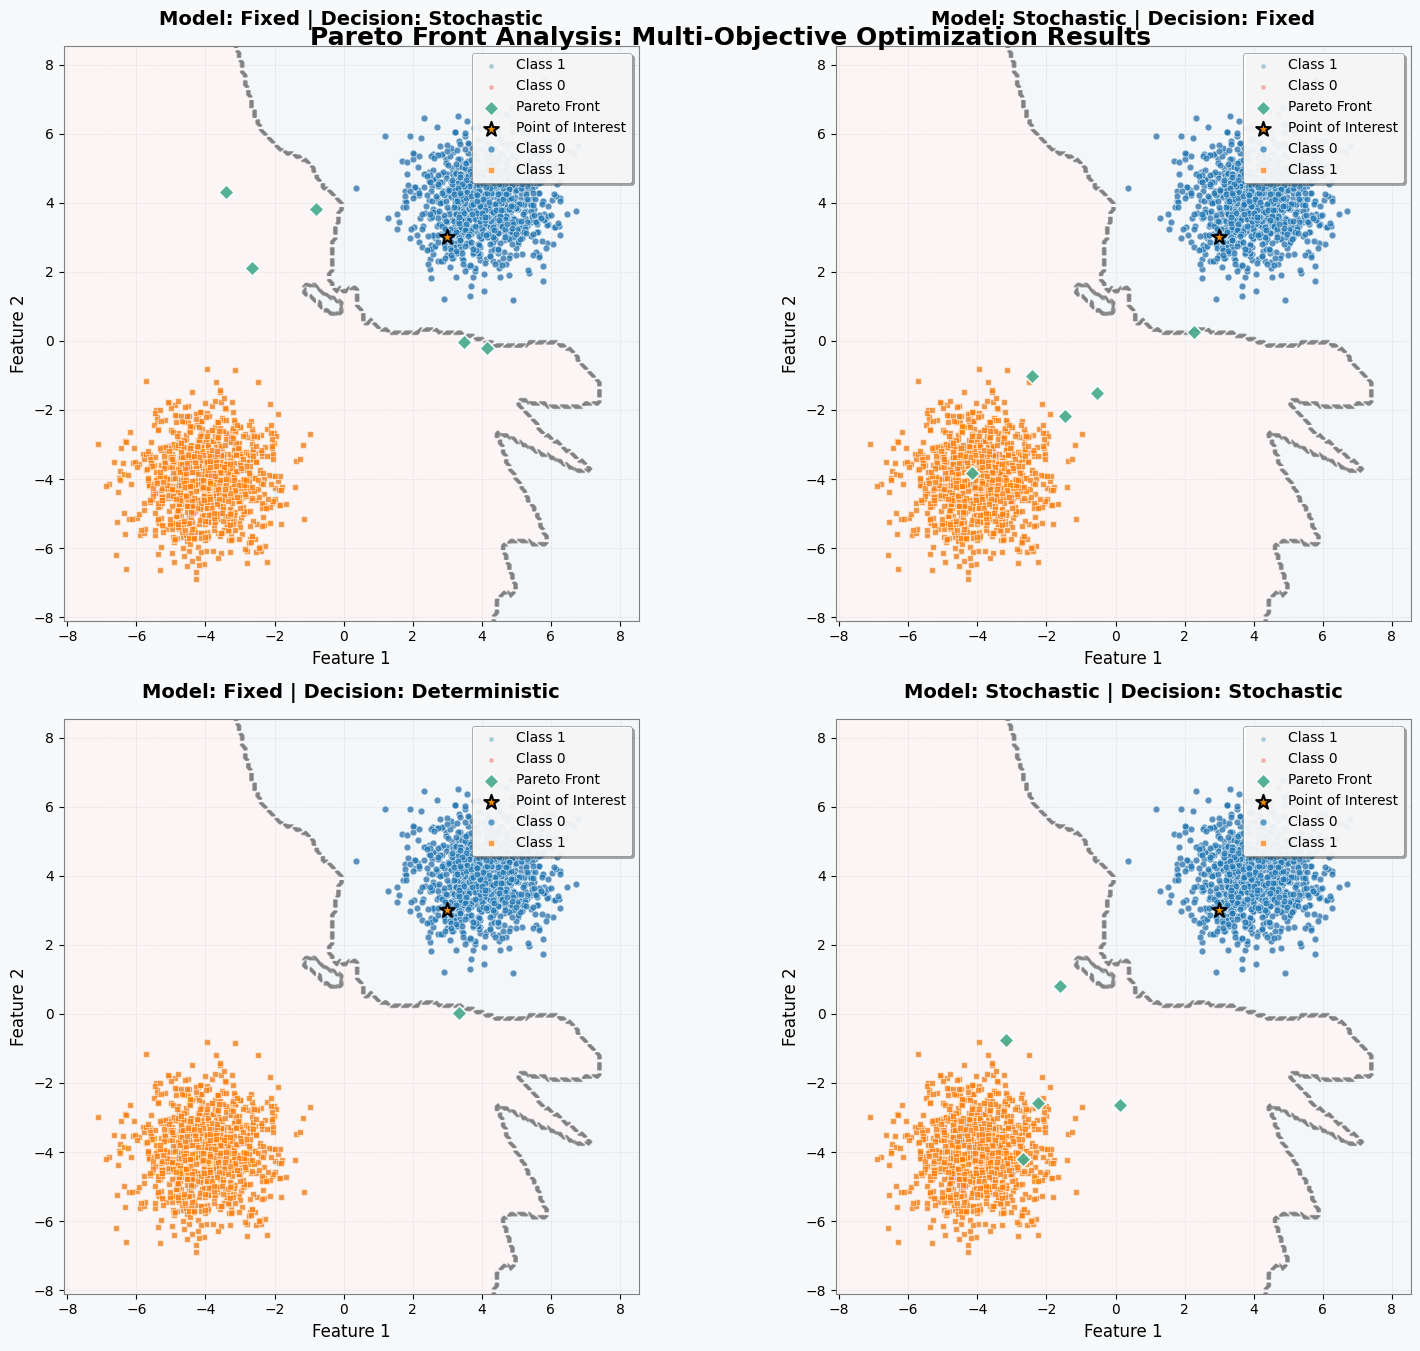

In [23]:
def visualize_pareto_front(ax, pareto_front,X,y, title):
    
    if len(pareto_front.shape) == 1:
        pareto_front = pareto_front[np.newaxis, :]

    # Enhanced color scheme and styling
    colors = {
        'label1': '#2E86AB',      # Professional blue
        'label0': '#F24236',      # Professional red
        'pareto': '#43AA8B',      # Teal green
        'poi': '#F18F01'          # Orange for point of interest
    }
    X_label1 = X[y == 1]
    X_label0 = X[y == 0]
    
    # Plot data points with improved styling
    ax.scatter(X_label1[:, 0], X_label1[:, 1], 
              s=12, alpha=0.4, c=colors['label1'], 
              label="Class 1", edgecolors='white', linewidth=0.3)
    ax.scatter(X_label0[:, 0], X_label0[:, 1], 
              s=12, alpha=0.4, c=colors['label0'], 
              label="Class 0", edgecolors='white', linewidth=0.3)
    
    # Plot Pareto front with enhanced styling
    ax.scatter(pareto_front[:, 0], pareto_front[:, 1],
              s=60, c=colors['pareto'], label="Pareto Front",
              edgecolors='white', linewidth=1.2, alpha=0.9,
              marker='D', zorder=5)
    
    # Add point of interest if it exists
    if 'point_of_interest' in globals():
        ax.scatter(point_of_interest[0,0], point_of_interest[0,1],
                  s=120, c=colors['poi'], marker='*', 
                  edgecolors='black', linewidth=1.5,
                  label="Point of Interest", zorder=6)
    
    # Visualize decision boundary
    visualize_decision_boundry(ax, X, ensemble_model, y, dataset_name="")
    
    # Enhanced styling
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Feature 1", fontsize=12, fontweight='medium')
    ax.set_ylabel("Feature 2", fontsize=12, fontweight='medium')
    
    # Improved legend
    legend = ax.legend(loc='upper right', frameon=True, fancybox=True, 
                      shadow=True, fontsize=10, framealpha=0.9)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('gray')
    legend.get_frame().set_linewidth(0.5)
    
    # Grid and styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#fafafa')
    
    # Set equal aspect ratio for better visualization
    ax.set_aspect('equal', adjustable='box')

fig, ax = plt.subplots(figsize=(16, 14), ncols=2, nrows=2)

# Set overall figure styling
fig.suptitle('Pareto Front Analysis: Multi-Objective Optimization Results', 
             fontsize=18, fontweight='bold', y=0.95)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Create each subplot with enhanced titles
visualize_pareto_front(ax[0,0], pareto_points_m_f_d_s, X,y,
                      "Model: Fixed | Decision: Stochastic")
visualize_pareto_front(ax[0,1], pareto_points_m_s_d_f, X,y,
                      "Model: Stochastic | Decision: Fixed")
visualize_pareto_front(ax[1,0], pareto_points_m_f_d_d, X,y,
                      "Model: Fixed | Decision: Deterministic")
visualize_pareto_front(ax[1,1], pareto_points_m_s_d_s, X,y,
                      "Model: Stochastic | Decision: Stochastic")

# Set consistent axis limits for all subplots
x_min, x_max = X.min() - 1, X.max() + 1
y_min, y_max = X.min() - 1, X.max() + 1

for i in range(2):
    for j in range(2):
        ax[i,j].set_xlim(x_min, x_max)
        ax[i,j].set_ylim(y_min, y_max)

# Add a subtle background color to the figure
fig.patch.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('pareto_front_comparison_bubbles.pdf', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### L-Dataset

In [24]:
ensemble_model.load("models/Ensemble_L_dataset_50/")

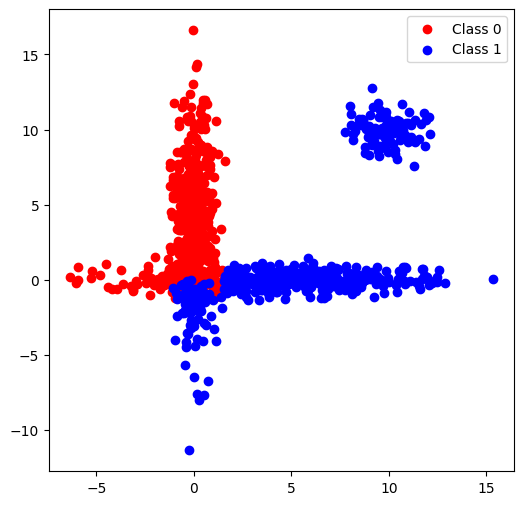

In [25]:
X,y,_ = load_l_dataset()
visualize_data(X,y)
point_of_interest = np.array([[0, 10]])

In [26]:
m_f_d_d = Model_Fixed_Decision_Deterministic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_f_d_s = Model_Fixed_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_f = Model_Stochastic_Decision_Fixed(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_s = Model_Stochastic_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)

algorithm = NSGA_II_Counterfactual(
    pop_size=5, original_point=point_of_interest, sigma_features=np.array([1, 1])
)

res_m_f_d_d = minimize(
    m_f_d_d, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_f_d_s = minimize(
    m_f_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_f = minimize(
    m_s_d_f, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_s = minimize(
    m_s_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)

pareto_points_m_f_d_d = res_m_f_d_d.X
objetives_m_f_d_d = res_m_f_d_d.F

pareto_points_m_f_d_s = res_m_f_d_s.X
objetives_m_f_d_s = res_m_f_d_s.F

pareto_points_m_s_d_f = res_m_s_d_f.X
objetives_m_s_d_f = res_m_s_d_f.F

pareto_points_m_s_d_s = res_m_s_d_s.X
objetives_m_s_d_s = res_m_s_d_s.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |        5 |      1 |  0.3087971306 |  0.4004591164 |             - |             -
     2 |       10 |      1 |  0.000000E+00 |  0.2755281763 |             - |             -
     3 |       15 |      1 |  0.000000E+00 |  0.1272258350 |  0.6681743157 |         ideal
     4 |       20 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |       25 |      1 |  0.000000E+00 |  0.000000E+00 |  4.0891196090 |         ideal
     6 |       30 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     7 |       35 |      1 |  0.000000E+00 |  0.000000E+00 |  0.3069518190 |         ideal
     8 |       40 |      1 |  0.000000E+00 |  0.000000E+00 |  0.2345338885 |         ideal
     9 |       45 |      1 |  0.000000E+00 |  0.000000E+00 |  0.3226962524 |         ideal
    10 |       50 |      1 |  0.000000E+00 |  0.000000E+00 |  0.6288880622 |         ideal

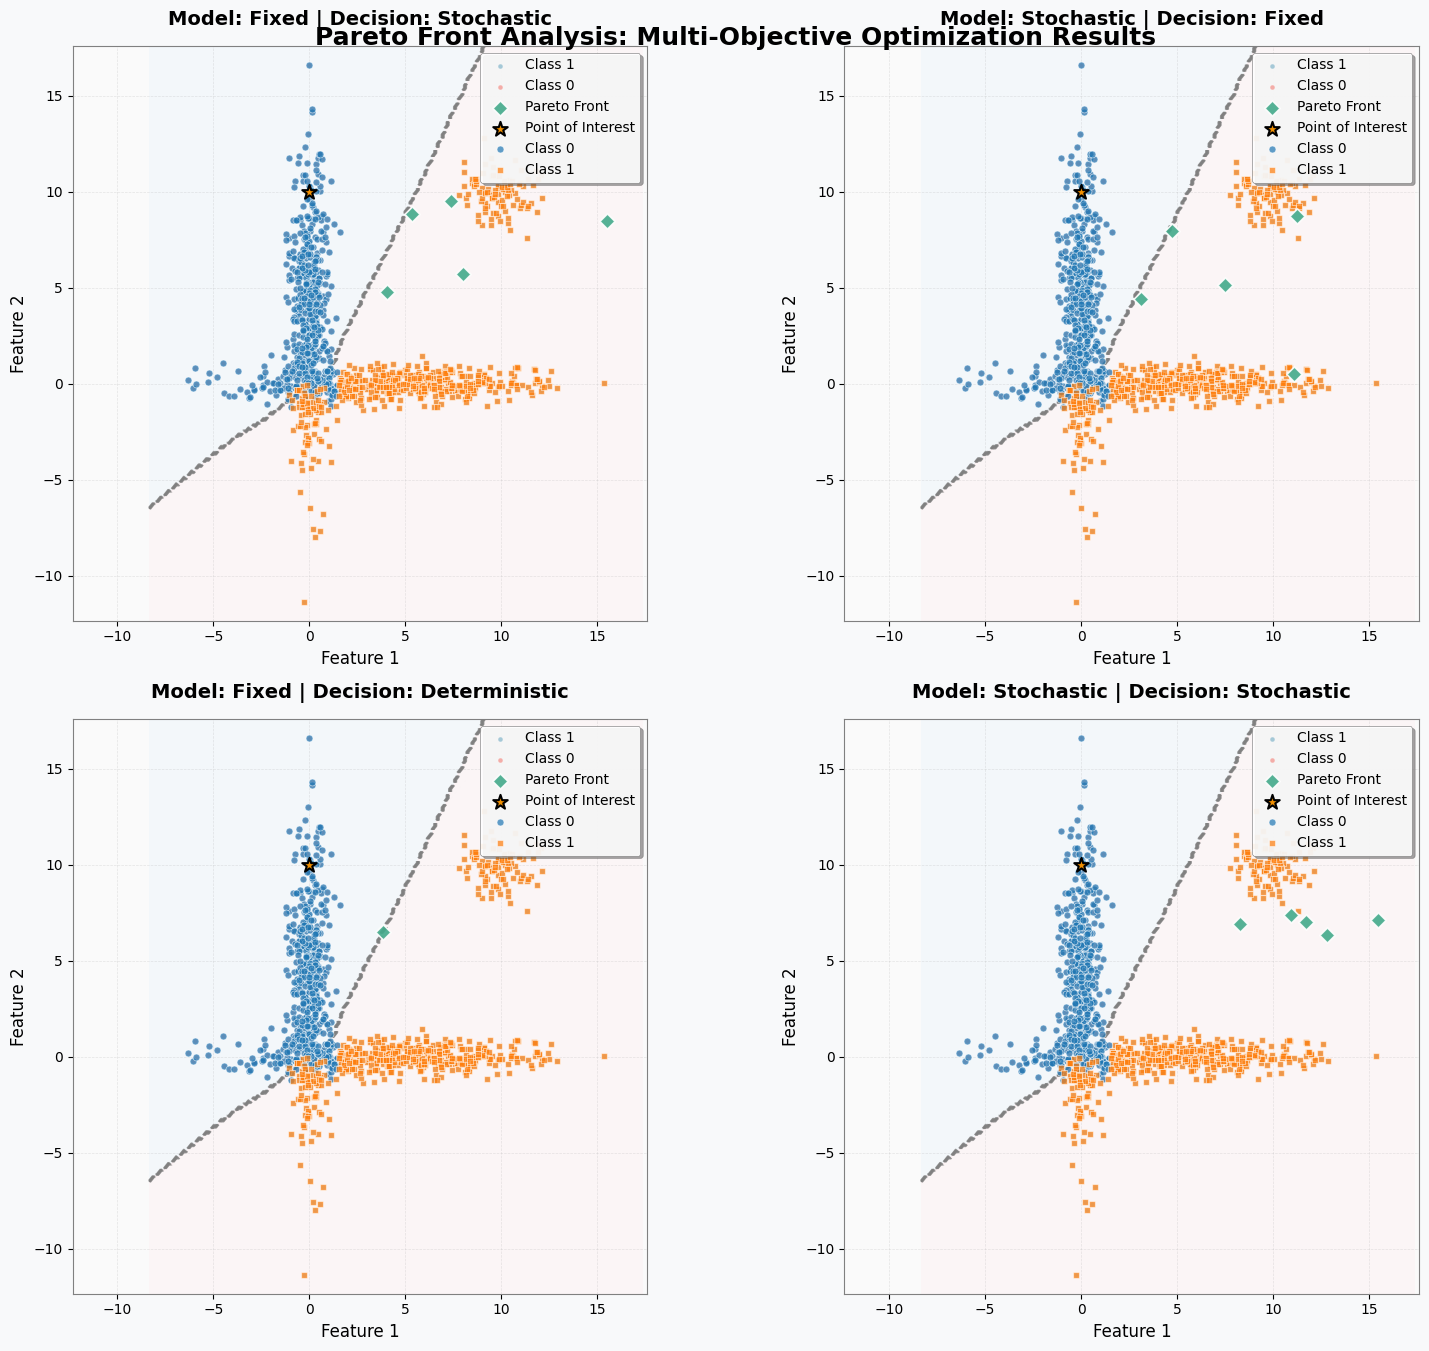

In [27]:
fig, ax = plt.subplots(figsize=(16, 14), ncols=2, nrows=2)

# Set overall figure styling
fig.suptitle(
    "Pareto Front Analysis: Multi-Objective Optimization Results",
    fontsize=18,
    fontweight="bold",
    y=0.95,
)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Create each subplot with enhanced titles
visualize_pareto_front(
    ax[0, 0], pareto_points_m_f_d_s, X, y, "Model: Fixed | Decision: Stochastic"
)
visualize_pareto_front(
    ax[0, 1], pareto_points_m_s_d_f, X, y, "Model: Stochastic | Decision: Fixed"
)
visualize_pareto_front(
    ax[1, 0], pareto_points_m_f_d_d, X, y, "Model: Fixed | Decision: Deterministic"
)
visualize_pareto_front(
    ax[1, 1], pareto_points_m_s_d_s, X, y, "Model: Stochastic | Decision: Stochastic"
)

# Set consistent axis limits for all subplots
x_min, x_max = X.min() - 1, X.max() + 1
y_min, y_max = X.min() - 1, X.max() + 1

for i in range(2):
    for j in range(2):
        ax[i, j].set_xlim(x_min, x_max)
        ax[i, j].set_ylim(y_min, y_max)

# Add a subtle background color to the figure
fig.patch.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.savefig(
    "pareto_front_comparison_L.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
plt.show()

### One Moon

In [28]:
ensemble_model.load("models/Ensemble_One_moon_50/")

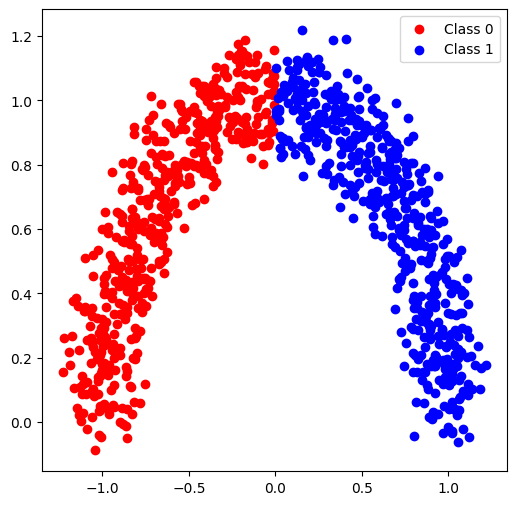

In [29]:
X, y, _ = load_one_moon()
visualize_data(X, y)
point_of_interest = np.array([[-1, 0]])

In [30]:
m_f_d_d = Model_Fixed_Decision_Deterministic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_f_d_s = Model_Fixed_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_f = Model_Stochastic_Decision_Fixed(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_s = Model_Stochastic_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)

algorithm = NSGA_II_Counterfactual(
    pop_size=5, original_point=point_of_interest, sigma_features=np.array([1, 1])
)

res_m_f_d_d = minimize(
    m_f_d_d, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_f_d_s = minimize(
    m_f_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_f = minimize(
    m_s_d_f, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_s = minimize(
    m_s_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)

pareto_points_m_f_d_d = res_m_f_d_d.X
objetives_m_f_d_d = res_m_f_d_d.F

pareto_points_m_f_d_s = res_m_f_d_s.X
objetives_m_f_d_s = res_m_f_d_s.F

pareto_points_m_s_d_f = res_m_s_d_f.X
objetives_m_s_d_f = res_m_s_d_f.F

pareto_points_m_s_d_s = res_m_s_d_s.X
objetives_m_s_d_s = res_m_s_d_s.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |        5 |      1 |  0.3150552756 |  0.3761900833 |             - |             -
     2 |       10 |      1 |  0.000000E+00 |  0.2204120623 |             - |             -
     3 |       15 |      1 |  0.000000E+00 |  0.0109386165 |  0.000000E+00 |             f
     4 |       20 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0366608607 |         ideal
     5 |       25 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     6 |       30 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0489580941 |         ideal
     7 |       35 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0012315079 |             f
     8 |       40 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0015775797 |             f
     9 |       45 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0015775797 |             f
    10 |       50 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0017055329 |             f

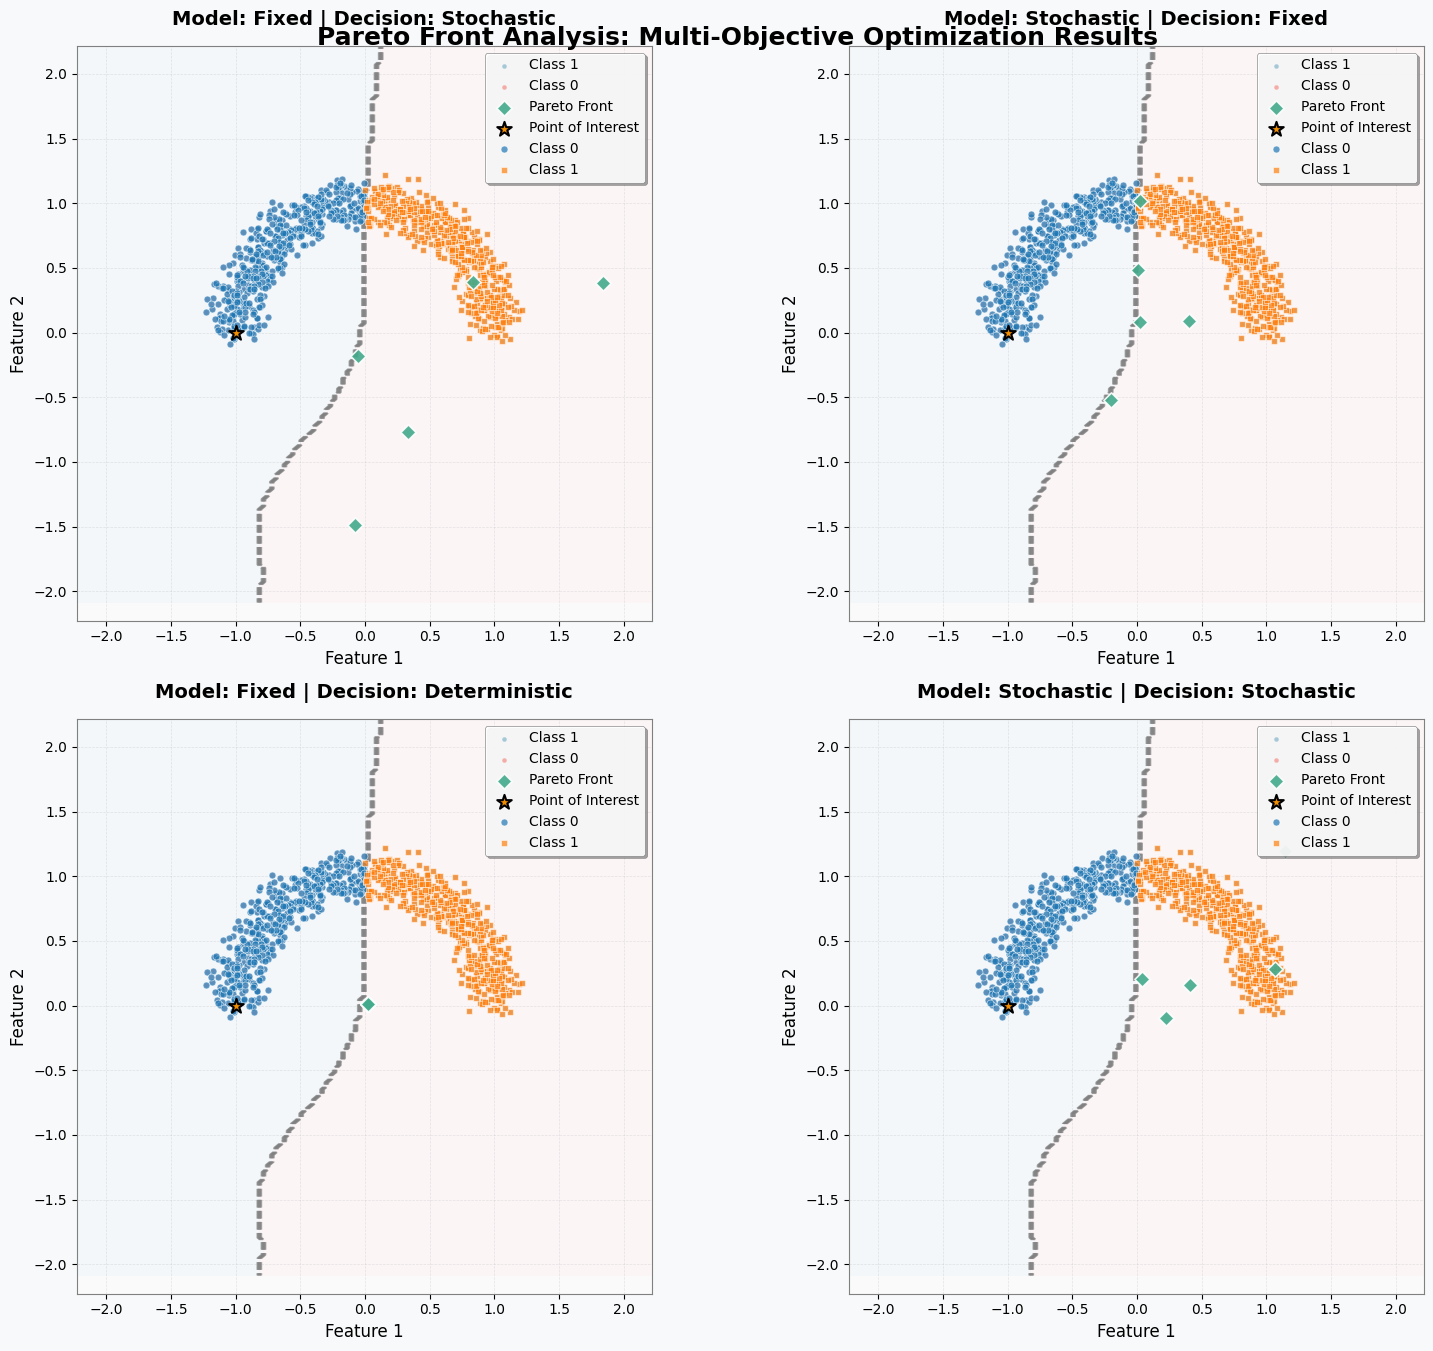

In [31]:
fig, ax = plt.subplots(figsize=(16, 14), ncols=2, nrows=2)

# Set overall figure styling
fig.suptitle(
    "Pareto Front Analysis: Multi-Objective Optimization Results",
    fontsize=18,
    fontweight="bold",
    y=0.95,
)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Create each subplot with enhanced titles
visualize_pareto_front(
    ax[0, 0], pareto_points_m_f_d_s, X, y, "Model: Fixed | Decision: Stochastic"
)
visualize_pareto_front(
    ax[0, 1], pareto_points_m_s_d_f, X, y, "Model: Stochastic | Decision: Fixed"
)
visualize_pareto_front(
    ax[1, 0], pareto_points_m_f_d_d, X, y, "Model: Fixed | Decision: Deterministic"
)
visualize_pareto_front(
    ax[1, 1], pareto_points_m_s_d_s, X, y, "Model: Stochastic | Decision: Stochastic"
)

# Set consistent axis limits for all subplots
x_min, x_max = X.min() - 1, X.max() + 1
y_min, y_max = X.min() - 1, X.max() + 1

for i in range(2):
    for j in range(2):
        ax[i, j].set_xlim(x_min, x_max)
        ax[i, j].set_ylim(y_min, y_max)

# Add a subtle background color to the figure
fig.patch.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.savefig(
    "pareto_front_comparison_one_moon.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
plt.show()

### Two Moon

In [32]:
ensemble_model.load("models/Ensemble_Two_moon_50/")

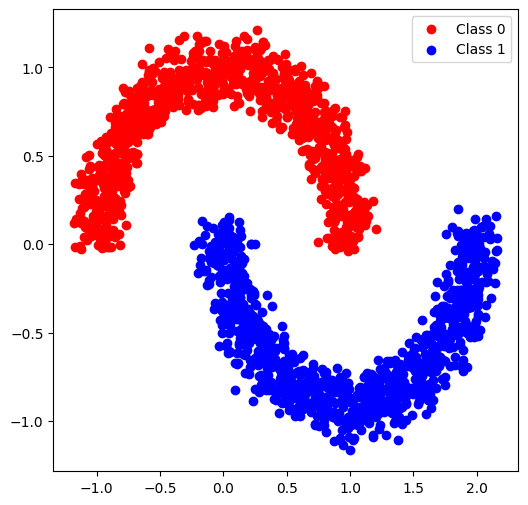

In [33]:
X, y, _ = load_two_moon()
visualize_data(X, y)
point_of_interest = np.array([[-1, 0]])

In [34]:
m_f_d_d = Model_Fixed_Decision_Deterministic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_f_d_s = Model_Fixed_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_f = Model_Stochastic_Decision_Fixed(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_s = Model_Stochastic_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)

algorithm = NSGA_II_Counterfactual(
    pop_size=5, original_point=point_of_interest, sigma_features=np.array([1, 1])
)

res_m_f_d_d = minimize(
    m_f_d_d, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_f_d_s = minimize(
    m_f_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_f = minimize(
    m_s_d_f, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_s = minimize(
    m_s_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)

pareto_points_m_f_d_d = res_m_f_d_d.X
objetives_m_f_d_d = res_m_f_d_d.F

pareto_points_m_f_d_s = res_m_f_d_s.X
objetives_m_f_d_s = res_m_f_d_s.F

pareto_points_m_s_d_f = res_m_s_d_f.X
objetives_m_s_d_f = res_m_s_d_f.F

pareto_points_m_s_d_s = res_m_s_d_s.X
objetives_m_s_d_s = res_m_s_d_s.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |        5 |      1 |  0.0382324851 |  0.2515884063 |             - |             -
     2 |       10 |      1 |  0.000000E+00 |  0.0374246159 |             - |             -
     3 |       15 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     4 |       20 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |       25 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     6 |       30 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     7 |       35 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0012456698 |             f
     8 |       40 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0024393753 |             f
     9 |       45 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0060413911 |         ideal
    10 |       50 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

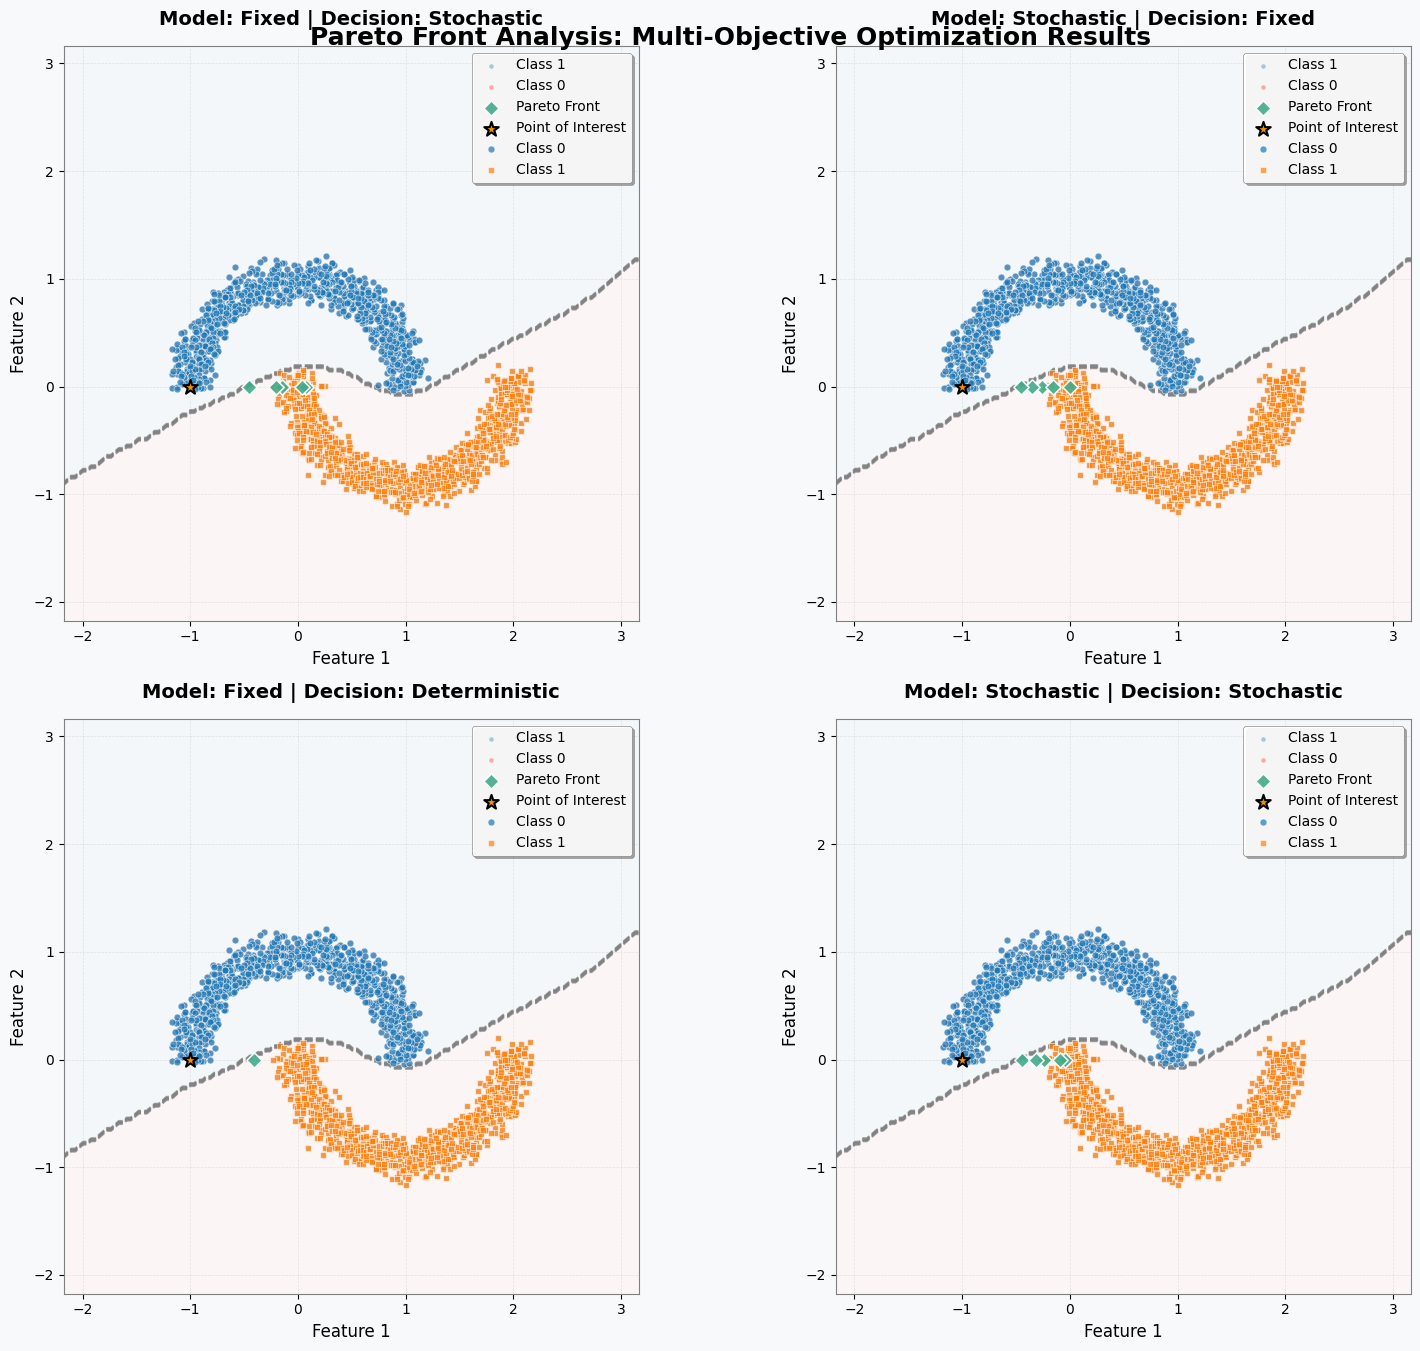

In [35]:
fig, ax = plt.subplots(figsize=(16, 14), ncols=2, nrows=2)

# Set overall figure styling
fig.suptitle(
    "Pareto Front Analysis: Multi-Objective Optimization Results",
    fontsize=18,
    fontweight="bold",
    y=0.95,
)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Create each subplot with enhanced titles
visualize_pareto_front(
    ax[0, 0], pareto_points_m_f_d_s, X, y, "Model: Fixed | Decision: Stochastic"
)
visualize_pareto_front(
    ax[0, 1], pareto_points_m_s_d_f, X, y, "Model: Stochastic | Decision: Fixed"
)
visualize_pareto_front(
    ax[1, 0], pareto_points_m_f_d_d, X, y, "Model: Fixed | Decision: Deterministic"
)
visualize_pareto_front(
    ax[1, 1], pareto_points_m_s_d_s, X, y, "Model: Stochastic | Decision: Stochastic"
)

# Set consistent axis limits for all subplots
x_min, x_max = X.min() - 1, X.max() + 1
y_min, y_max = X.min() - 1, X.max() + 1

for i in range(2):
    for j in range(2):
        ax[i, j].set_xlim(x_min, x_max)
        ax[i, j].set_ylim(y_min, y_max)

# Add a subtle background color to the figure
fig.patch.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.savefig(
    "pareto_front_comparison_two_moon.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
plt.show()

### Ring Dataset

In [36]:
ensemble_model.load("models/Ensemble_Ring_dataset_50/")

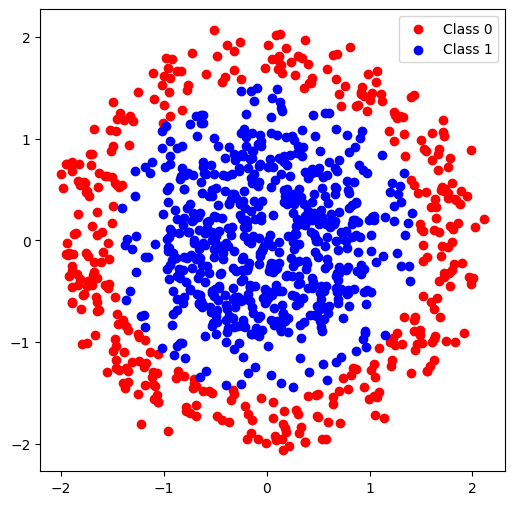

In [37]:
X, y, _ = load_ring_dataset()
visualize_data(X, y)
point_of_interest = np.array([[-1, -2]])

In [38]:
m_f_d_d = Model_Fixed_Decision_Deterministic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_f_d_s = Model_Fixed_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_f = Model_Stochastic_Decision_Fixed(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_s = Model_Stochastic_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)

algorithm = NSGA_II_Counterfactual(
    pop_size=5, original_point=point_of_interest, sigma_features=np.array([1, 1])
)

res_m_f_d_d = minimize(
    m_f_d_d, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_f_d_s = minimize(
    m_f_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_f = minimize(
    m_s_d_f, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_s = minimize(
    m_s_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)

pareto_points_m_f_d_d = res_m_f_d_d.X
objetives_m_f_d_d = res_m_f_d_d.F

pareto_points_m_f_d_s = res_m_f_d_s.X
objetives_m_f_d_s = res_m_f_d_s.F

pareto_points_m_s_d_f = res_m_s_d_f.X
objetives_m_s_d_f = res_m_s_d_f.F

pareto_points_m_s_d_s = res_m_s_d_s.X
objetives_m_s_d_s = res_m_s_d_s.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |        5 |      1 |  0.000000E+00 |  0.2989839004 |             - |             -
     2 |       10 |      1 |  0.000000E+00 |  0.1381775507 |  0.000000E+00 |             f
     3 |       15 |      1 |  0.000000E+00 |  0.000000E+00 |  0.1789526649 |         ideal
     4 |       20 |      1 |  0.000000E+00 |  0.000000E+00 |  0.6126407569 |         ideal
     5 |       25 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0095783849 |         ideal
     6 |       30 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0290585460 |         ideal
     7 |       35 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     8 |       40 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0113567028 |         ideal
     9 |       45 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0065851308 |         ideal
    10 |       50 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

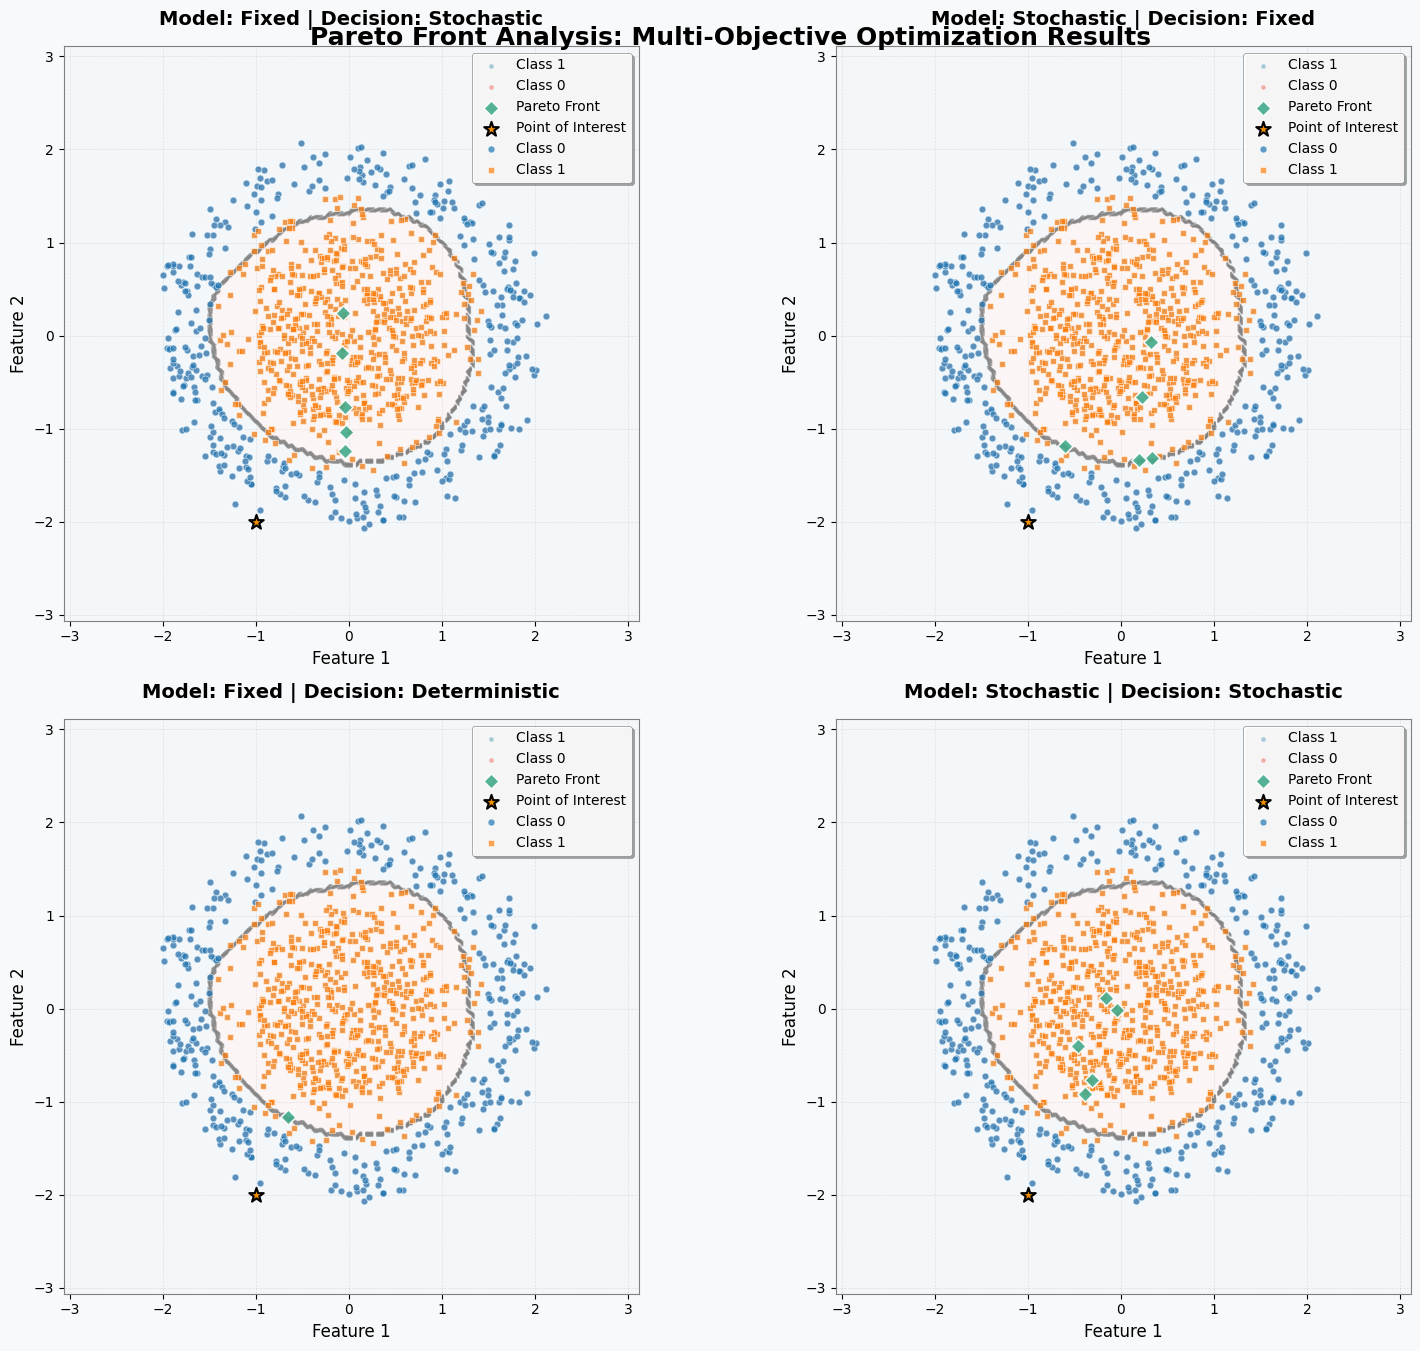

In [39]:
fig, ax = plt.subplots(figsize=(16, 14), ncols=2, nrows=2)

# Set overall figure styling
fig.suptitle(
    "Pareto Front Analysis: Multi-Objective Optimization Results",
    fontsize=18,
    fontweight="bold",
    y=0.95,
)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Create each subplot with enhanced titles
visualize_pareto_front(
    ax[0, 0], pareto_points_m_f_d_s, X, y, "Model: Fixed | Decision: Stochastic"
)
visualize_pareto_front(
    ax[0, 1], pareto_points_m_s_d_f, X, y, "Model: Stochastic | Decision: Fixed"
)
visualize_pareto_front(
    ax[1, 0], pareto_points_m_f_d_d, X, y, "Model: Fixed | Decision: Deterministic"
)
visualize_pareto_front(
    ax[1, 1], pareto_points_m_s_d_s, X, y, "Model: Stochastic | Decision: Stochastic"
)

# Set consistent axis limits for all subplots
x_min, x_max = X.min() - 1, X.max() + 1
y_min, y_max = X.min() - 1, X.max() + 1

for i in range(2):
    for j in range(2):
        ax[i, j].set_xlim(x_min, x_max)
        ax[i, j].set_ylim(y_min, y_max)

# Add a subtle background color to the figure
fig.patch.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.savefig(
    "pareto_front_comparison_ring.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
plt.show()

### Infinity Dataset

In [40]:
ensemble_model.load("models/Ensemble_Infinity_dataset_50/")

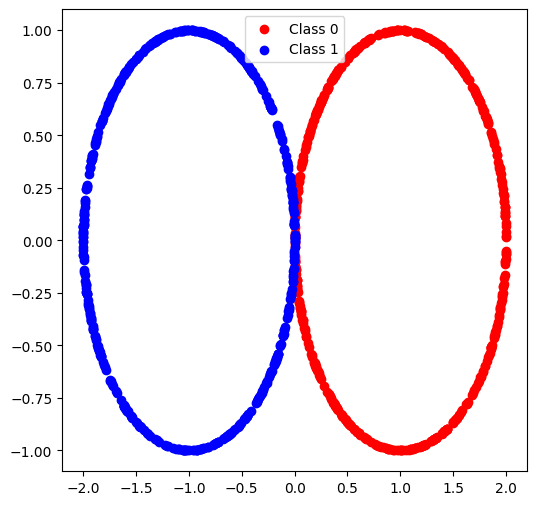

In [41]:
X, y, _ = load_infinity_dataset()
visualize_data(X, y)
point_of_interest = np.array([[2, 0]])

In [42]:
m_f_d_d = Model_Fixed_Decision_Deterministic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_f_d_s = Model_Fixed_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_f = Model_Stochastic_Decision_Fixed(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)
m_s_d_s = Model_Stochastic_Decision_Stochastic(
    ensemble_model, point_of_interest, X.min(), X.max(), 2, get_costs
)

algorithm = NSGA_II_Counterfactual(
    pop_size=5, original_point=point_of_interest, sigma_features=np.array([1, 1])
)

res_m_f_d_d = minimize(
    m_f_d_d, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_f_d_s = minimize(
    m_f_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_f = minimize(
    m_s_d_f, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)
res_m_s_d_s = minimize(
    m_s_d_s, algorithm, termination=termination, seed=1, save_history=True, verbose=True
)

pareto_points_m_f_d_d = res_m_f_d_d.X
objetives_m_f_d_d = res_m_f_d_d.F

pareto_points_m_f_d_s = res_m_f_d_s.X
objetives_m_f_d_s = res_m_f_d_s.F

pareto_points_m_s_d_f = res_m_s_d_f.X
objetives_m_s_d_f = res_m_s_d_f.F

pareto_points_m_s_d_s = res_m_s_d_s.X
objetives_m_s_d_s = res_m_s_d_s.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |        5 |      1 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |       10 |      1 |  0.000000E+00 |  0.000000E+00 |  0.8108889336 |         ideal
     3 |       15 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     4 |       20 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |       25 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0350689720 |         ideal
     6 |       30 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0105655055 |         ideal
     7 |       35 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     8 |       40 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0018627629 |             f
     9 |       45 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0023754378 |             f
    10 |       50 |      1 |  0.000000E+00 |  0.000000E+00 |  0.0032983096 |         ideal

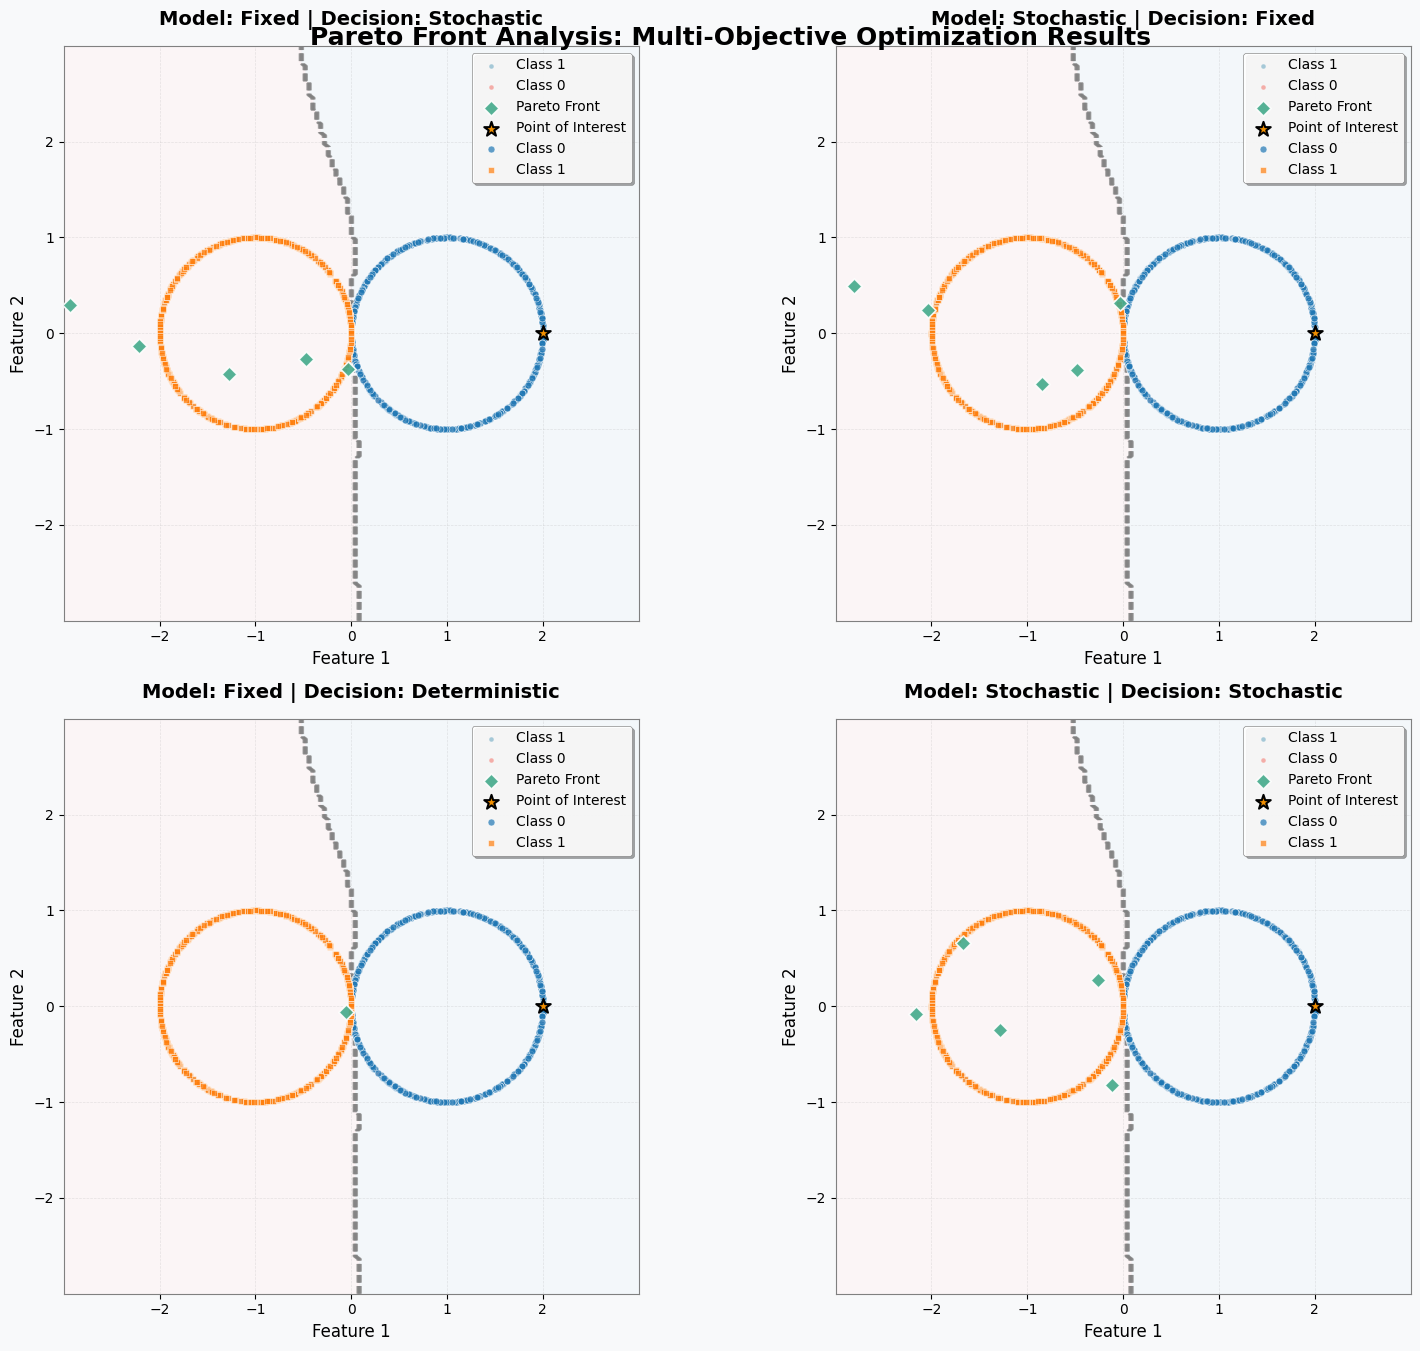

In [43]:
fig, ax = plt.subplots(figsize=(16, 14), ncols=2, nrows=2)

# Set overall figure styling
fig.suptitle(
    "Pareto Front Analysis: Multi-Objective Optimization Results",
    fontsize=18,
    fontweight="bold",
    y=0.95,
)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Create each subplot with enhanced titles
visualize_pareto_front(
    ax[0, 0], pareto_points_m_f_d_s, X, y, "Model: Fixed | Decision: Stochastic"
)
visualize_pareto_front(
    ax[0, 1], pareto_points_m_s_d_f, X, y, "Model: Stochastic | Decision: Fixed"
)
visualize_pareto_front(
    ax[1, 0], pareto_points_m_f_d_d, X, y, "Model: Fixed | Decision: Deterministic"
)
visualize_pareto_front(
    ax[1, 1], pareto_points_m_s_d_s, X, y, "Model: Stochastic | Decision: Stochastic"
)

# Set consistent axis limits for all subplots
x_min, x_max = X.min() - 1, X.max() + 1
y_min, y_max = X.min() - 1, X.max() + 1

for i in range(2):
    for j in range(2):
        ax[i, j].set_xlim(x_min, x_max)
        ax[i, j].set_ylim(y_min, y_max)

# Add a subtle background color to the figure
fig.patch.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.savefig(
    "pareto_front_comparison_infinity.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
)
plt.show()

### MNIST

-----STARTING COUNTERFACTUAL GENERATION------
DESIRED_CLASS:  5
LATENT_DIM:  16


/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Image with low probability:  0.8403400182723999
Image shape:  torch.Size([1, 28, 28])
SEARCH SPACE:  -3 3
ALGORITHM:  <moo_nsgaii.algorithm.NSGA_II_Counterfactual object at 0x11171db70>
TERMINATION:  <pymoo.termination.max_gen.MaximumGenerationTermination object at 0x37e6984f0>
	 max_gen 400
____FINISHED SAMPLING____
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      400 |      1 |  0.2495095730 |  0.4131546967 |             - |             -
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      400 |      1 |  0.2495095730 |  0.4131546967 |             - |             -


/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/pymoo/operators/crossover/sbx.py:47: RuntimeWarning: invalid value encountered in power
  betaq[mask] = np.power((rand * alpha), (1.0 / (eta + 1.0)))[mask]


     2 |      800 |      1 |  0.2495095730 |  0.3556518300 |             - |             -
     3 |     1200 |      1 |  0.2038076520 |  0.3423561119 |             - |             -
     3 |     1200 |      1 |  0.2038076520 |  0.3423561119 |             - |             -
     4 |     1600 |      1 |  0.2038076520 |  0.3311283046 |             - |             -
     4 |     1600 |      1 |  0.2038076520 |  0.3311283046 |             - |             -
     5 |     2000 |      1 |  0.2038076520 |  0.3152189759 |             - |             -
     5 |     2000 |      1 |  0.2038076520 |  0.3152189759 |             - |             -
     6 |     2400 |      1 |  0.1904502511 |  0.2982855769 |             - |             -
     6 |     2400 |      1 |  0.1904502511 |  0.2982855769 |             - |             -
     7 |     2800 |      1 |  0.1599999964 |  0.2892354817 |             - |             -
     7 |     2800 |      1 |  0.1599999964 |  0.2892354817 |             - |             -

KeyboardInterrupt: 

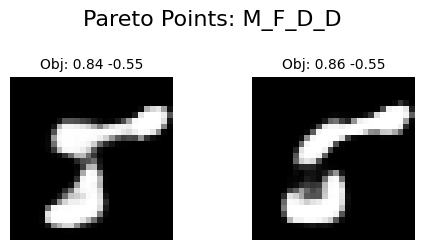

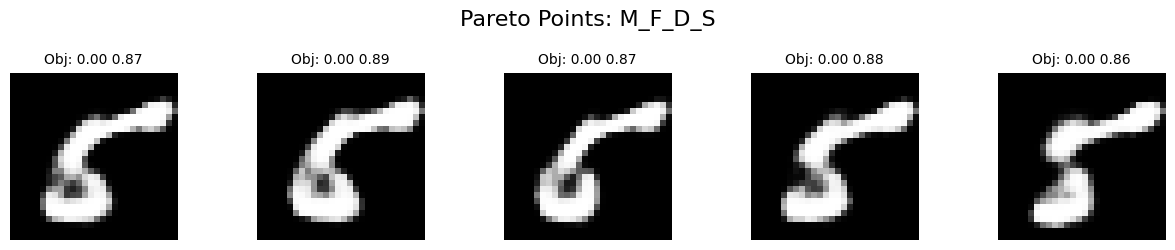

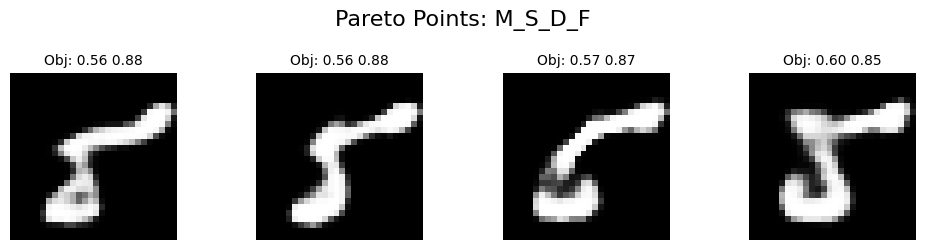

In [44]:
import torch
import os
from MOO_MNIST import (
    load_mnist,
    load_epistemic_model,
    load_vae,
    load_point_of_interest,
    get_costs_mnist,
    load_pymoo_problems,
    get_algorithm_setup,
    get_pareto_front,
    visualize_pareto_point,)

LATENT_DIM = 16
DESIRED_CLASS = 5

np.random.seed(42)
torch.manual_seed(42)
print("-----STARTING COUNTERFACTUAL GENERATION------")
print("DESIRED_CLASS: ", DESIRED_CLASS)
print("LATENT_DIM: ", LATENT_DIM)
os.makedirs(f"moo_mnist/{DESIRED_CLASS}", exist_ok=True)
trainloader, testloader = load_mnist()
epiuc_ensemble = load_epistemic_model()
vae = load_vae(LATENT_DIM)
point_of_interest = load_point_of_interest(epiuc_ensemble, testloader)

min_val, max_val = -3, 3
print("SEARCH SPACE: ", min_val, max_val)
m_f_d_d, m_f_d_s, m_s_d_f, m_s_d_s = load_pymoo_problems(
    epiuc_ensemble,
    vae,
    point_of_interest,
    min_val,
    max_val,
    get_costs_mnist,
    LATENT_DIM,
    DESIRED_CLASS,
)

for name,problem in {"M_F_D_D": m_f_d_d, "M_F_D_S": m_f_d_s, "M_S_D_F": m_s_d_f, "M_S_D_S": m_s_d_s}.items():
    algorithm,termination = get_algorithm_setup(vae, point_of_interest,n_obj=problem.n_obj, population_size=400)
    points,objectives = get_pareto_front(problem, algorithm, termination=termination)
    if points is None:
        warning.warn(f"No Pareto points found for {name}.")
        continue
    visualize_pareto_point(vae,points, objectives, name, latent_dim=LATENT_DIM)
    del points

print("Pareto fronts visualized.")